In [1]:
%load_ext autoreload
%autoreload 2
import moabb
from moabb.datasets import *
from moabb.evaluations import WithinSessionEvaluation
from moabb.paradigms import P300
from hoda.hoda import HODA,BTTDA
from sklearn.pipeline import make_pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler
import matplotlib.pyplot as plt
import seaborn as sns
from moabb.analysis.plotting import paired_plot, meta_analysis_plot, summary_plot
from sklearn.base import BaseEstimator, ClassifierMixin
from toeplitzlda.classification import ToeplitzLDA
from sklearn.svm import SVC
from moabb.analysis.meta_analysis import (  # noqa: E501
    compute_dataset_statistics,
    find_significant_differences,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
from matplotlib import style
plt.style.use('default')

In [3]:
tmin = 0
tmax=0.8
fmin=0.5
fmax = 16
sfreq = 64

paradigm = P300(resample=sfreq, tmin=tmin, tmax=tmax, fmin=fmin, fmax=fmax)
datasets = [
    #bi2013a(),
    #bi2014a(),
    #bi2014b(),
    #bi2015a(),
    #bi2015b(),
    BNCI2014008(),
    #BNCI2014009(),
    #BNCI2015003(),
    #DemonsP300(),
    #EPFLP300(),
    #Huebner2017(),
    #Huebner2018(),
    #Lee2019_ERP(),
    #Sosulski2019()

]
evaluation = WithinSessionEvaluation(
    paradigm=paradigm, datasets=datasets,
    suffix="hoda", overwrite=True,
        #data_size=dict(policy='per_class', value=[75,77]), n_perms=[5,5],
)

In [4]:
for dataset in datasets:
    print(dataset)
    dataset.download()

Creating RawArray with float64 data, n_channels=10, n_times=347704
    Range : 0 ... 347703 =      0.000 ...  1358.215 secs
Ready.
Creating RawArray with float64 data, n_channels=10, n_times=347704
    Range : 0 ... 347703 =      0.000 ...  1358.215 secs
Ready.
Creating RawArray with float64 data, n_channels=10, n_times=347704
    Range : 0 ... 347703 =      0.000 ...  1358.215 secs
Ready.
Creating RawArray with float64 data, n_channels=10, n_times=347704
    Range : 0 ... 347703 =      0.000 ...  1358.215 secs
Ready.
Creating RawArray with float64 data, n_channels=10, n_times=347704
    Range : 0 ... 347703 =      0.000 ...  1358.215 secs
Ready.
Creating RawArray with float64 data, n_channels=10, n_times=347704
    Range : 0 ... 347703 =      0.000 ...  1358.215 secs
Ready.
Creating RawArray with float64 data, n_channels=10, n_times=347704
    Range : 0 ... 347703 =      0.000 ...  1358.215 secs
Ready.
Creating RawArray with float64 data, n_channels=10, n_times=347704
    Range : 0 ..

In [5]:
import tensorly as tl
tl.set_backend('cupy', local_threadsafe=False)

In [6]:
import numpy as np

class ToeplitzLDAWrapper(BaseEstimator, ClassifierMixin):

    def fit(self, X, y=None):
        n_epochs, n_channels, n_samples = X.shape
        self.tlda_ = ToeplitzLDA(n_channels=n_channels,
                                 data_is_channel_prime=False)
        X = X.reshape(n_epochs, -1)
        return self.tlda_.fit(X, y)

    def decision_function(self, X):
        n_epochs, n_channels, n_samples = X.shape
        X = X.reshape(n_epochs, -1)
        return self.tlda_.decision_function(X)

    def predict(self, X):
        n_epochs, n_channels, n_samples = X.shape
        X = X.reshape(n_epochs, -1)
        return self.tlda_.predict(X)

    def predict_proba(self, X):
        n_epochs, n_channels, n_samples = X.shape
        X = X.reshape(n_epochs, -1)
        return self.tlda_.predict_proba(X)



def lagged_tensor(X, y=None):    
    window = 0.4
    max_lag = 0.4
    
    n_epochs, n_channels, _ = X.shape
    roi0 = int((0 - tmin)*sfreq)
    roi1 = int((window - tmin)*sfreq)
    n_times = roi1-roi0
    n_lags= int(max_lag*sfreq)
    Xt = np.zeros((n_epochs, n_channels, n_times, n_lags))
    for l in range(n_lags):
        Xt[:,:,:,l] = X[:,:,roi0+l:roi1+l]
    return Xt

def reshape(X, y=None):
    return X.reshape((X.shape[0],-1))

def tril_reshape(X):
    tril_idc = np.tril_indices(X.shape[-1])
    Xt = np.zeros((*X.shape[:2], len(tril_idc[0])))
    for i in range(Xt.shape[0]):
        for c in range(Xt.shape[1]):
            Xt[i,c] = X[i,c][tril_idc]
    Xt = Xt.reshape((Xt.shape[0],-1))
    return Xt


In [7]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.svm import SVC
from sklearn.feature_selection import SelectPercentile, f_classif
import cupy

pipelines = dict()


pipelines['HODA_fixed'] = make_pipeline(
    Scaler(scalings='mean', with_mean=False),
    HODA(
        max_iter=128,
        rank=[3,3],
        tol=1e-3,
        init ='mlsvd',
        shrinkage=('oas', 'oas'),
        toeplitz=(1,),
        solver='diff',
        verbose=False,
    ),
    FunctionTransformer(reshape),
    LinearDiscriminantAnalysis()
)

pipelines['HODA_od'] = make_pipeline(
    Scaler(scalings='mean', with_mean=False),
    HODA(
        max_iter=128,
        rank=None,
        tol=1e-3,
        init ='mlsvd',
        shrinkage=('oas', 'oas'),
        toeplitz=(1,),
        solver='diff',
        verbose=False,
    ),
    FunctionTransformer(reshape),
    LinearDiscriminantAnalysis(),
)
"""

pipelines['BTTDA'] = make_pipeline(
    Scaler(scalings='mean', with_mean=False),
    BTTDA(
        n_blocks=8,
        hoda_params=dict(
        max_iter=128,
        rank=None,
        explain=1,
        tol=1e-4,
        init ='mlsvd',
        shrinkage=(0,0),
        toeplitz=(1,),
        solver='ratio_svd',
        verbose=False,
        keep_train_info=False
        ),
    ),
    #SelectPercentile(percentile=50, score_func=f_classif),
    LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')
)

pipelines['tLDA'] = make_pipeline(
    Scaler(scalings='mean', with_mean=False),
    ToeplitzLDAWrapper()
)
"""

"\n\npipelines['BTTDA'] = make_pipeline(\n    Scaler(scalings='mean', with_mean=False),\n    BTTDA(\n        n_blocks=8,\n        hoda_params=dict(\n        max_iter=128,\n        rank=None,\n        explain=1,\n        tol=1e-4,\n        init ='mlsvd',\n        shrinkage=(0,0),\n        toeplitz=(1,),\n        solver='ratio_svd',\n        verbose=False,\n        keep_train_info=False\n        ),\n    ),\n    #SelectPercentile(percentile=50, score_func=f_classif),\n    LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')\n)\n\npipelines['tLDA'] = make_pipeline(\n    Scaler(scalings='mean', with_mean=False),\n    ToeplitzLDAWrapper()\n)\n"

In [8]:
tl.set_backend('cupy')

In [9]:
results = evaluation.process(pipelines)

008-2014-WithinSession:   0%|                                                                   | 0/8 [00:00<?, ?it/s]/home/arne/.virtualenvs/hoda/lib/python3.11/site-packages/tensorly/backend/core.py:1106: UserWarning: In partial_svd: converting to NumPy. Check SVD_FUNS for available alternatives if you want to avoid this.
  warnings.warn('In partial_svd: converting to NumPy.'
/home/arne/.virtualenvs/hoda/lib/python3.11/site-packages/tensorly/backend/core.py:1106: UserWarning: In partial_svd: converting to NumPy. Check SVD_FUNS for available alternatives if you want to avoid this.
  warnings.warn('In partial_svd: converting to NumPy.'
/home/arne/.virtualenvs/hoda/lib/python3.11/site-packages/tensorly/backend/core.py:1106: UserWarning: In partial_svd: converting to NumPy. Check SVD_FUNS for available alternatives if you want to avoid this.
  warnings.warn('In partial_svd: converting to NumPy.'
/home/arne/.virtualenvs/hoda/lib/python3.11/site-packages/tensorly/backend/core.py:1106: User

008-2014-WithinSession:  38%|██████████████████████▏                                    | 3/8 [00:26<00:42,  8.52s/it]/home/arne/.virtualenvs/hoda/lib/python3.11/site-packages/tensorly/backend/core.py:1106: UserWarning: In partial_svd: converting to NumPy. Check SVD_FUNS for available alternatives if you want to avoid this.
  warnings.warn('In partial_svd: converting to NumPy.'
/home/arne/.virtualenvs/hoda/lib/python3.11/site-packages/tensorly/backend/core.py:1106: UserWarning: In partial_svd: converting to NumPy. Check SVD_FUNS for available alternatives if you want to avoid this.
  warnings.warn('In partial_svd: converting to NumPy.'
/home/arne/.virtualenvs/hoda/lib/python3.11/site-packages/tensorly/backend/core.py:1106: UserWarning: In partial_svd: converting to NumPy. Check SVD_FUNS for available alternatives if you want to avoid this.
  warnings.warn('In partial_svd: converting to NumPy.'
/home/arne/.virtualenvs/hoda/lib/python3.11/site-packages/tensorly/backend/core.py:1106: User

008-2014-WithinSession:  75%|████████████████████████████████████████████▎              | 6/8 [00:54<00:19,  9.60s/it]/home/arne/.virtualenvs/hoda/lib/python3.11/site-packages/tensorly/backend/core.py:1106: UserWarning: In partial_svd: converting to NumPy. Check SVD_FUNS for available alternatives if you want to avoid this.
  warnings.warn('In partial_svd: converting to NumPy.'
/home/arne/.virtualenvs/hoda/lib/python3.11/site-packages/tensorly/backend/core.py:1106: UserWarning: In partial_svd: converting to NumPy. Check SVD_FUNS for available alternatives if you want to avoid this.
  warnings.warn('In partial_svd: converting to NumPy.'
/home/arne/.virtualenvs/hoda/lib/python3.11/site-packages/tensorly/backend/core.py:1106: UserWarning: In partial_svd: converting to NumPy. Check SVD_FUNS for available alternatives if you want to avoid this.
  warnings.warn('In partial_svd: converting to NumPy.'
/home/arne/.virtualenvs/hoda/lib/python3.11/site-packages/tensorly/backend/core.py:1106: User

In [10]:
results

,score,time,samples,subject,session,channels,n_sessions,dataset,pipeline
0,0.813198,0.780707,4200.0,1,session_0,8,1,008-2014,HODA_od
1,0.745955,0.738504,4200.0,2,session_0,8,1,008-2014,HODA_od
2,0.872743,0.598010,4200.0,3,session_0,8,1,008-2014,HODA_od
3,0.805396,0.573160,4200.0,4,session_0,8,1,008-2014,HODA_od
4,0.843606,0.642166,4200.0,5,session_0,8,1,008-2014,HODA_od
5,0.844155,0.972067,4200.0,6,session_0,8,1,008-2014,HODA_od
6,0.838071,0.727756,4200.0,7,session_0,8,1,008-2014,HODA_od
7,0.943469,0.587196,4200.0,8,session_0,8,1,008-2014,HODA_od
8,0.781935,0.566610,4200.0,1,session_0,8,1,008-2014,HODA_fixed
9,0.714290,0.451580,4200.0,2,session_0,8,1,008-2014,HODA_fixed


/home/arne/.virtualenvs/hoda/lib/python3.11/site-packages/moabb/analysis/meta_analysis.py:26: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  return df.groupby(["pipeline", "dataset", "subject"]).mean().reset_index()


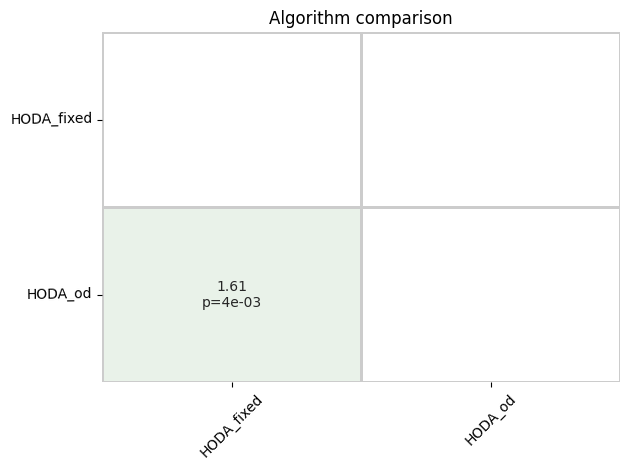

In [11]:
stats = compute_dataset_statistics(results)
P, T = find_significant_differences(stats)
_ = summary_plot(P, T)

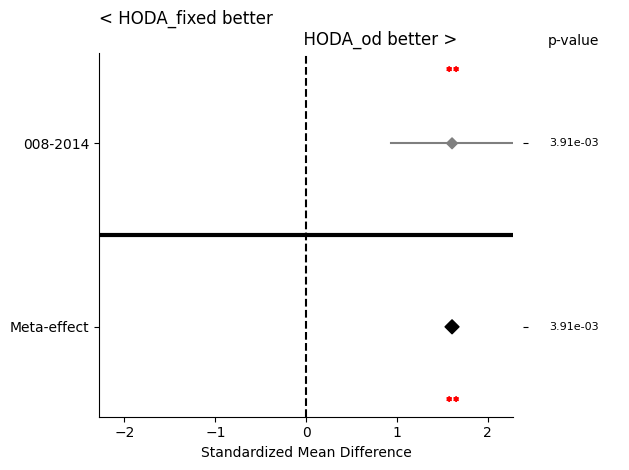

In [13]:

_=meta_analysis_plot(stats, "HODA_od", "HODA_fixed")


/home/arne/.virtualenvs/hoda/lib/python3.11/site-packages/moabb/analysis/meta_analysis.py:26: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  return df.groupby(["pipeline", "dataset", "subject"]).mean().reset_index()


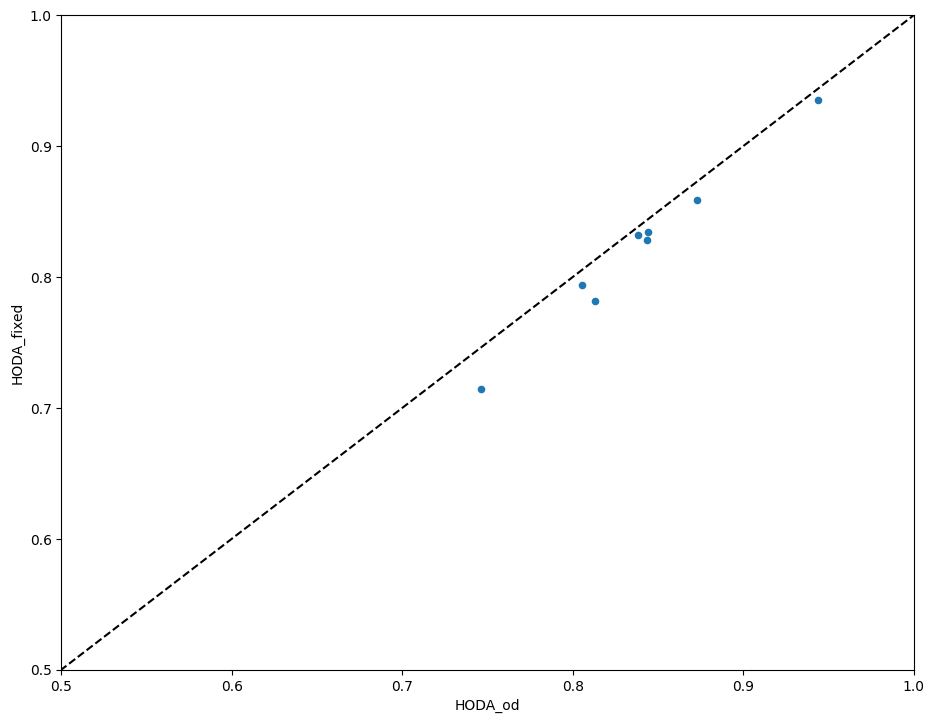

In [14]:
_ = paired_plot(results, "HODA_od", "HODA_fixed")
